<a href="https://colab.research.google.com/github/zcflanzer/rcew-water-budget/blob/main/116b_discharge_calculations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Annual discharge magnitude calculations normalized by watershed area
Created by Zoe Flanzer

Data: hourly data at rcew 116b stream gauge

In [ ]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from google.colab import files

# defining years filtered
start_yr = 2000
end_yr = 2024

# defining watershed area
watershed_area_m2 = 54742541 # m2

In [ ]:
# importing discharge data file
df = pd.read_excel('/content/drive/MyDrive/Thesis/Data/Discharge/116b_q.xlsx')

In [ ]:
# defining function to get water year dates
def wy_dates(date):
  if date.month >= 10:
    return date.year + 1 # if month is oct, nov, dec then it's the following water year
  else:
    return date.year # otherwise it is the labeled year's water year

In [ ]:
# filtering data by water year
df['DateTime'] = pd.to_datetime(df['datetime'], errors ='coerce', format='%Y-%m-%d %H:%M') # converting datetime in excelt to datetime format
df['Water Year'] = df['DateTime'].apply(wy_dates) # adding water year column to df and applying water year function
df_filtered = df[(df['Water Year'] >= start_yr) & (df['Water Year'] <= end_yr) & (df['Water Year']) != end_yr ] # filtering df to include only select water years

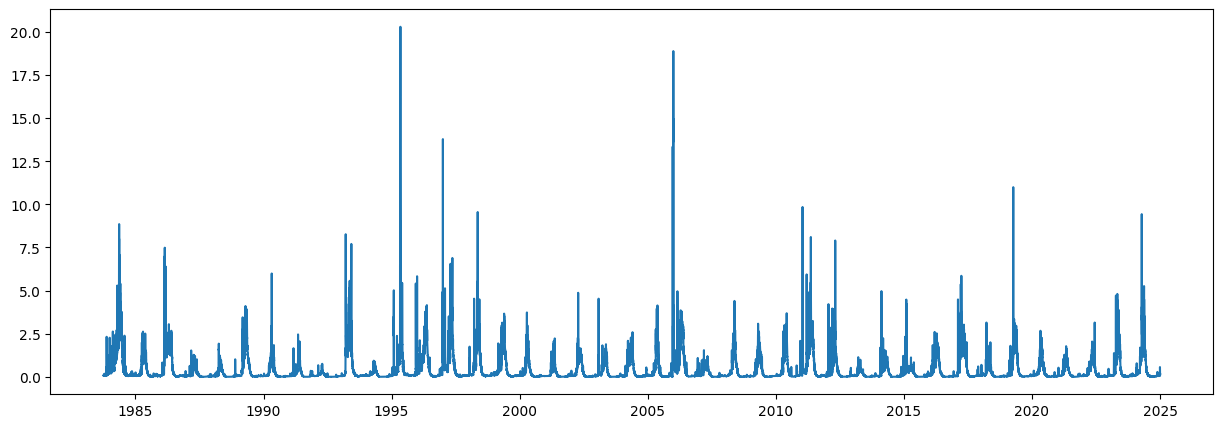

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(df['DateTime'], df['q (m^3/s)'])

In [ ]:
# calculating annual discharge magnitudes

# creating empty lists
all_wyd = []
all_discharge = []
annual_discharge = []
years = []

# filtering through data for each individual water year
for wy in range(start_yr, end_yr + 1):

  # filtering data for each water year
  d_wy = df_filtered[df_filtered['Water Year'] == wy]
  discharge_f = d_wy['q (m^3/s)'].values

  # calculating annual discharge
  hrly = discharge_f * 60 * 60 # converting from m^3/s to m^3/hr
  annual = np.sum(hrly) # summing hourly measurements for each year==> m^3/yr

  # normalizing by watershed area
  norm_annual = annual / watershed_area_m2 # m/yr
  norm_annual_cm = norm_annual * 100 # m to cm

  # appending data to lists
  annual_discharge.append(norm_annual_cm)
  years.append(wy)
  all_wyd.append(d_wy)
  all_discharge.append(discharge_f)

  # printing discharge of each year
  print(f'Normalized annual discharge in {wy}: {norm_annual_cm} cm/yr')

Normalized annual discharge in 2000: 14.731898357454764 cm/yr
Normalized annual discharge in 2001: 9.734440894930328 cm/yr
Normalized annual discharge in 2002: 17.00098709357317 cm/yr
Normalized annual discharge in 2003: 14.060998037529812 cm/yr
Normalized annual discharge in 2004: 18.790915408884654 cm/yr
Normalized annual discharge in 2005: 16.450963519435522 cm/yr
Normalized annual discharge in 2006: 40.138135166082265 cm/yr
Normalized annual discharge in 2007: 9.820528961704749 cm/yr
Normalized annual discharge in 2008: 19.223123917519676 cm/yr
Normalized annual discharge in 2009: 16.295558512355164 cm/yr
Normalized annual discharge in 2010: 20.998887320871713 cm/yr
Normalized annual discharge in 2011: 43.10835874542981 cm/yr
Normalized annual discharge in 2012: 20.609324553529675 cm/yr
Normalized annual discharge in 2013: 6.533915066531544 cm/yr
Normalized annual discharge in 2014: 12.495868329650635 cm/yr
Normalized annual discharge in 2015: 11.639979038459321 cm/yr
Normalized an

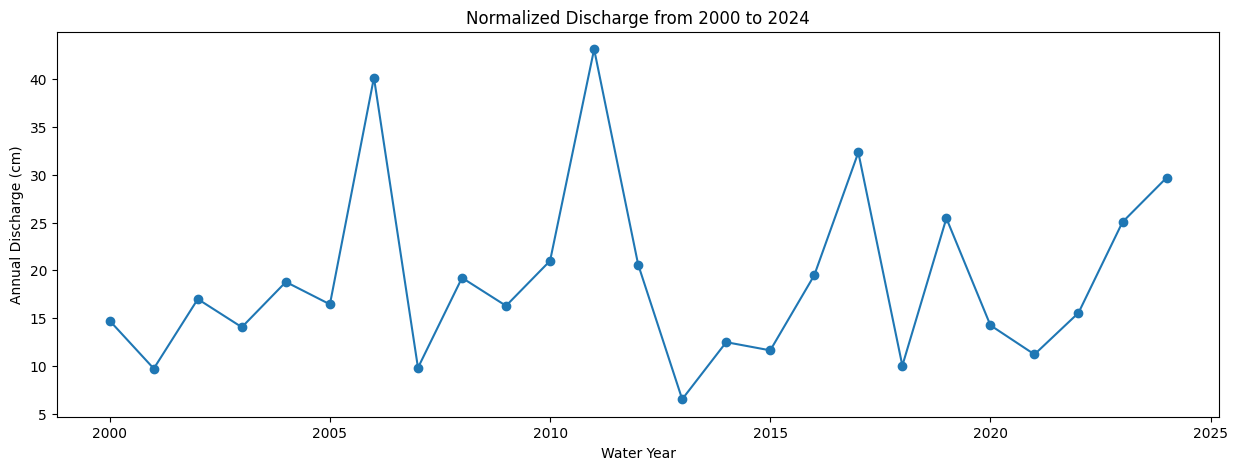

In [ ]:
# plotting annual discharge magnitudes
discharge_over_time = plt.figure(figsize=(15, 5))
plt.plot(years, annual_discharge, marker='o')
plt.xlabel('Water Year')
plt.ylabel('Annual Discharge (cm)')
plt.title(f'Normalized Discharge from {start_yr} to {end_yr}')
plt.show()

In [ ]:
# calculating statistics
# pearson correlation coefficient and p-value
pearson_correlation, p_value = pearsonr(years, annual_discharge)
print(f'pearson correlation coefficient: {pearson_correlation}, p-value: {p_value}')

# spearman correlation coefficient and p-value
spearman_correlation, p_value = spearmanr(years, annual_discharge)
print(f'spearman correlation coefficient: {spearman_correlation}, p-value: {p_value}')

pearson correlation coefficient: 0.12212352368707985, p-value: 0.5608765521004185
spearman correlation coefficient: 0.1623076923076923, p-value: 0.4382499479372728


In [ ]:
# saving data to csv in drive
df_yrly = pd.DataFrame({'discharge_yr': years, 'discharge_cm': annual_discharge})
df_yrly.to_csv('/content/drive/MyDrive/Thesis/Data/Discharge/annual_discharge.csv')

# downloading figure
discharge_over_time.savefig('discharge_over_time.png', dpi=300, bbox_inches='tight') # saving figure
files.download('discharge_over_time.png') # downloading

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>